# Ottimizzazione numerica

### Introduzione

L’ottimizzazione è il settore della matematica che studia come individuare la soluzione migliore tra tutte quelle possibili. In termini matematici, questo significa spesso determinare il punto in cui una funzione assume il suo valore minimo o massimo. I problemi di minimo sono particolarmente importanti perché molte situazioni reali possono essere descritte come la ricerca della configurazione che riduce al minimo un costo, un errore, un consumo di risorse o una distanza rispetto a un obiettivo.

Esempi di problemi di ottimizzazione compaiono in moltissimi ambiti. Nell’ingegneria si cerca di progettare strutture efficienti e resistenti utilizzando la minore quantità possibile di materiale. Nella logistica si vogliono ridurre i tempi e i costi di trasporto. Nell’elaborazione delle immagini si cerca una ricostruzione che sia allo stesso tempo fedele ai dati osservati e priva di rumore. In economia si ottimizzano profitti, investimenti e allocazione delle risorse.

L’ottimizzazione riveste un ruolo centrale anche nell’analisi dei dati, nel machine learning e nelle reti neurali. In questi contesti si introduce generalmente una funzione di costo, o funzione di perdita, che misura quanto le previsioni del modello siano lontane dai valori desiderati. Addestrare un modello significa quindi trovare i valori dei suoi parametri che rendono questa funzione il più piccola possibile.

Nel caso di una rete neurale, i parametri da determinare sono i pesi e i bias dei diversi strati. Poiché il loro numero può essere molto elevato, il problema di ottimizzazione è generalmente multidimensionale. Il gradiente della funzione di costo indica la direzione in cui la funzione cresce più rapidamente; muovendosi nella direzione opposta si cerca quindi di ridurne il valore. Questa idea è alla base del metodo del gradiente discendente e di molti degli algoritmi utilizzati per l’addestramento delle reti neurali.

Lo studio del gradiente, della matrice hessiana e delle derivate di funzioni di più variabili permette quindi non solo di descrivere il comportamento locale di una funzione, ma anche di costruire metodi numerici in grado di individuare in modo efficiente punti di minimo.


Data una funzione 

$$ 
f:\Omega \subset R^n \rightarrow R 
$$ 

matematicamente il problema si formula come un problema di minimo.

$$
argmin_{x \in \Omega} f(x)
$$ 

oppure di massimo:

$$
argmax_{x \in \Omega} f(x)
$$

cioè si ricerca l'ascissa del punto di minimo o di massimo della funzione.

I due problemi sono equivalenti semplicemente cambiando il segno della funzione, cioè se $f(x)$ è continua e limitata, 

$$
argimn_{x \in \Omega} f(x)=argmax_{x \in \Omega} -f(x).
$$ 

Quindi di solito si studia solo il problema di minimizzare una funzione, al quale ci si può sempre facilmente ricondurre.

L’insieme $\Omega$, spesso detto insieme dei valori accettabili o insieme dei vincoli, descrive sotto quali ipotesi la soluzione 
 del problema deve sottostare per essere dichiarata accettabile.

```{note}
Quanto appena descritto rappresenta un procedimento chiamato **modellizzazione matematica**, in cui un processo viene descritto matematicamente assegnando delle variabili e delle funzioni ai vari elementi del processo. Questo tipo di approccio è tipico di praticamente qualunque applicazione, ed è necessario prenderci la mano per capire bene il resto del corso.
```

In base alla forma dell'insieme $\Omega$ dei vincoli, oltre che alle proprietà matematiche della funzione obiettivo $f(x)$, i problemi di ottimizzazione si classificano in varie categorie. 

Partendo dalla scelta di $\Omega$, riconosciamo due classi principali:

* Se $\Omega = \mathbb{R}^n$, allora diciamo che il problema è **non vincolato** (*unconstrained*, in Inglese)
* Se $\Omega \subset \mathbb{R}^n$, allora diciamo che il problema è **vincolato** (*constrained*, in Inglese)

Ulteriori classificazioni si hanno considerando altre proprietà della funzione obiettivo. Ad esempio:

* Se $f(x) = x^T w$ è una funzione lineare in $x$, allora il problema è detto **lineare**,
* Se $f(x) = x^T A x + x^T b$ è una funzione quadratica in $x$, allora il problema è detto **quadratico**.

```{note}
In questo corso tratteremo ottimizzazione non vincolata.
```

### Definizioni: punti di minimo

-  $x^*$ è un punto di **minimo locale** di $f(x)$ se
esiste un $\epsilon>0$ tale

 $$f(x^*)\leq f(x) \quad \text{per ogni } x \text{ tale che }
    \|x-x^*\|<\epsilon$$

- $x^*$ è un punto di **minimo locale in senso
stretto** di $f(x)$ se esiste un $\epsilon>0$ tale

$$f(x^*) < f(x) \quad \text{per ogni }  x \text{ tale che }
    \|x-x^*\|<\epsilon, \quad x\neq x^*$$

-  $x^*$ è un punto di **minimo globale** di $f(x)$ se

$$f(x^*)\leq f(x) \quad \text{per ogni } x \in {R}^n$$

- $x^*$ è un punto di **minimo globale in senso
stretto** di $f(x)$ se

$$f(x^*) < f(x) \quad \text{per ogni } x \in {R}^n, \quad x\neq x^*$$

## Applicazione: una funzione di costo

Consideriamo la funzione di costo

$$
L(w_1,w_2)
=
(w_1-1)^2+2(w_2+1)^2.
$$

Questa funzione misura la distanza, opportunamente pesata, del vettore $(w_1,w_2)$ dal punto $(1,-1)$.

Il gradiente è

$$
\nabla L(w_1,w_2)
=
\begin{pmatrix}
2(w_1-1)\\
4(w_2+1)
\end{pmatrix}.
$$

Ponendo il gradiente uguale a zero,

$$
\begin{cases}
2(w_1-1)=0,\\
4(w_2+1)=0,
\end{cases}
$$

si ottiene

$$
w_1=1,
\qquad
w_2=-1.
$$

La matrice hessiana è

$$
\nabla^2 L(w_1,w_2)
=
\begin{pmatrix}
2 & 0\\
0 & 4
\end{pmatrix}.
$$

Poiché entrambi gli autovalori sono positivi, il punto $(1,-1)$ è un minimo.

Inoltre, poiché la funzione è quadratica e strettamente convessa, tale minimo è globale.

Un passo del metodo del gradiente discendente ha la forma

$$
\begin{pmatrix}
w_1^{(k+1)}\\
w_2^{(k+1)}
\end{pmatrix}
=
\begin{pmatrix}
w_1^{(k)}\\
w_2^{(k)}
\end{pmatrix}
-
\alpha
\nabla L\left(w_1^{(k)},w_2^{(k)}\right),
$$

dove $\alpha>0$ è il passo di apprendimento.

Questa formula costituisce la base di numerosi algoritmi utilizzati nell'ottimizzazione numerica e nel machine learning.

---

## Schema riassuntivo

| Oggetto | Tipo di funzione | Dimensione | Contenuto |
|---|---|---|---|
| Gradiente | $f:\mathbb{R}^n\to\mathbb{R}$ | $n\times 1$ | derivate prime |
| Hessiano | $f:\mathbb{R}^n\to\mathbb{R}$ | $n\times n$ | derivate seconde |
| Jacobiano | $F:\mathbb{R}^n\to\mathbb{R}^m$ | $m\times n$ | derivate prime delle componenti |

In particolare,

$$
\nabla f(\mathbf{x})
=
\begin{pmatrix}
\partial f/\partial x_1\\
\vdots\\
\partial f/\partial x_n
\end{pmatrix},
$$

$$
\nabla^2 f(\mathbf{x})
=
\left[
\frac{\partial^2 f}{\partial x_i\partial x_j}
\right]_{i,j=1}^n,
$$

$$
J_F(\mathbf{x})
=
\left[
\frac{\partial F_i}{\partial x_j}
\right]_{\substack{i=1,\ldots,m\\j=1,\ldots,n}}.
$$

---


### Esercizio 5

Determinare e classificare i punti stazionari delle funzioni

$$
f_1(x,y)=x^2+4y^2,
$$

$$
f_2(x,y)=x^2-y^2,
$$

$$
f_3(x,y)=-x^2-y^2.
$$


### Esempi di minimi

Una funzione $f$ può avere un punto di minimo locale e tuttavia non avere un punto di minimo globale. Può inoltre non avere né minimi locali né globali, oppure avere sia minimi locali sia minimi globali.

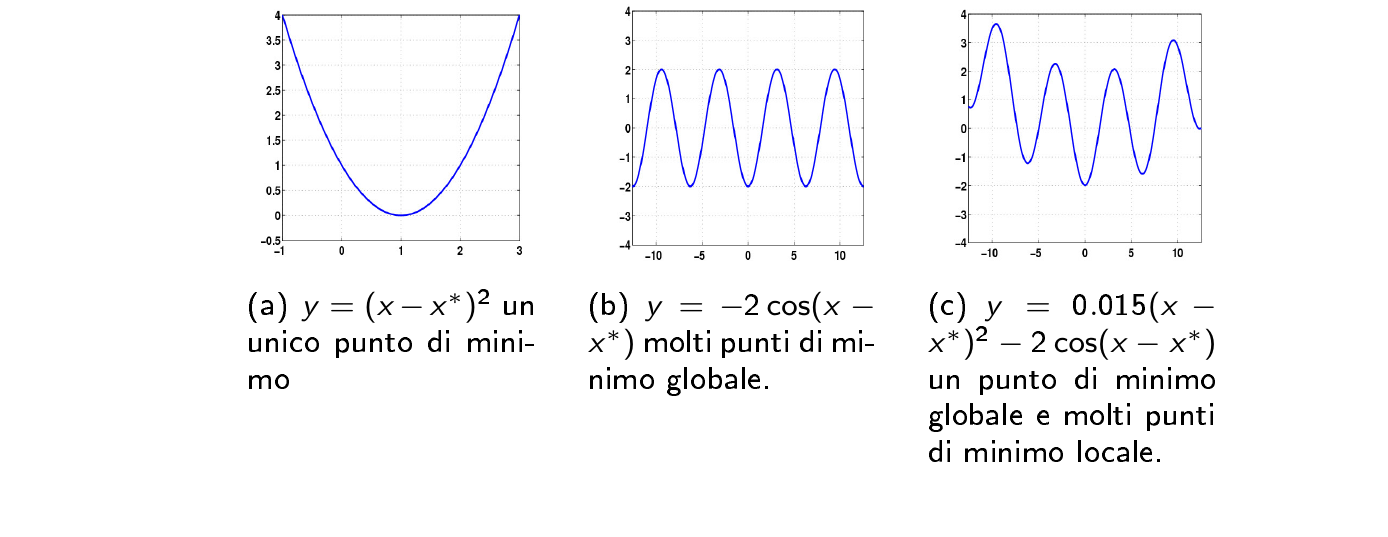

- $y=(x-x^*)^2$: un unico punto di minimo;
- $y=-2\cos(x-x^*)$: molti punti di minimo globale;
- $y=0.015(x-x^*)^2-2\cos(x-x^*)$: un punto di minimo globale e molti punti di minimo locale.


### Minimi locali e globali

La figura seguente distingue graficamente minimi locali, minimi locali stretti e un minimo globale stretto.

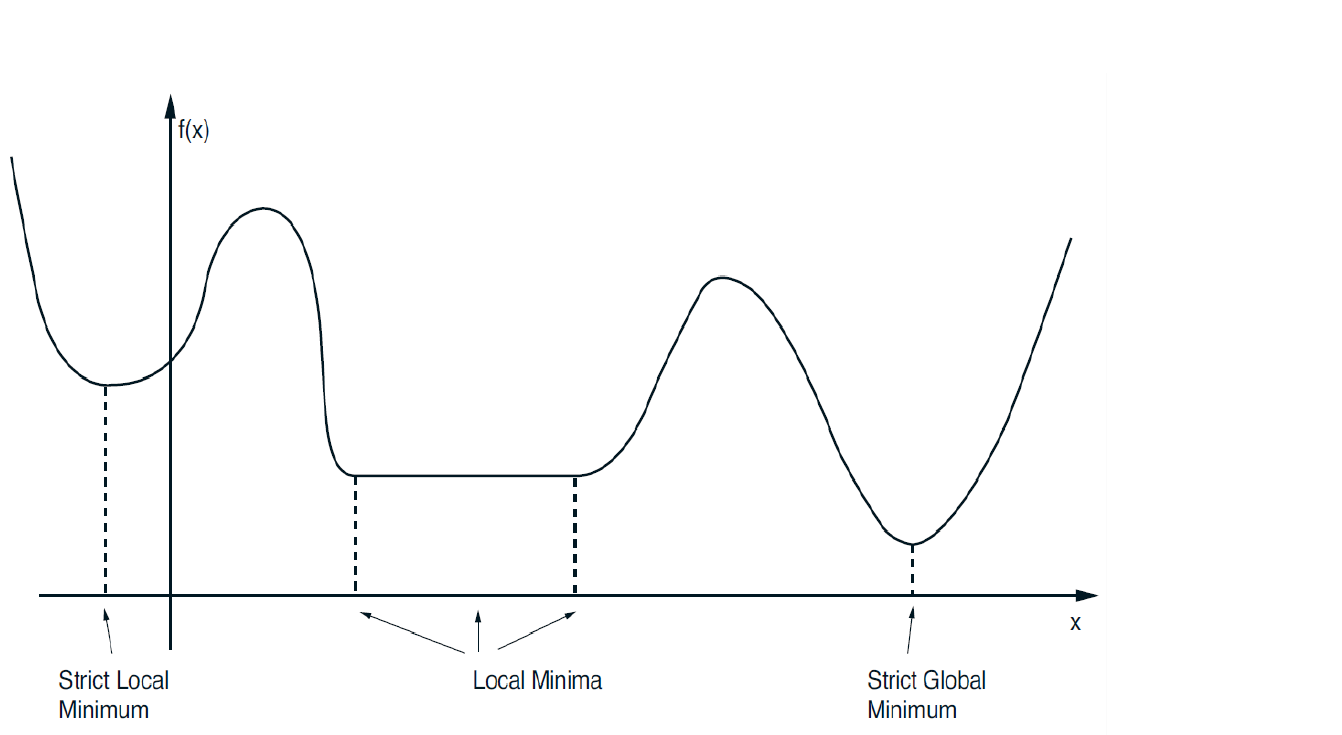


### Punti di massimo locale e globale

I punti di massimo locale e globale di $f$ sono definiti in maniera analoga ai punti di minimo.

Il problema di determinare un punto di massimo locale della funzione $f$ può essere ricondotto al problema di determinare un punto di minimo locale di $-f$:

$$
\max_{\mathbf{x}} f(\mathbf{x})
=
-\min_{\mathbf{x}}\bigl(-f(\mathbf{x})\bigr).
$$


## Condizioni di esistenza

### Teorema di Weierstrass

> **Proposizione.** Sia $S\subset\mathbb{R}^n$ un insieme compatto e non vuoto e sia $f:S\to\mathbb{R}$ una funzione continua su $S$. Allora esiste un punto di minimo globale di $f$ su $S$.

Il teorema di Weierstrass fornisce una condizione di esistenza soltanto **sufficiente** e si applica direttamente quando $S$ è compatto.


### Insiemi di livello

Siano $f:\mathbb{R}^n\to\mathbb{R}$ e $\alpha\in\mathbb{R}$.

Si definisce **insieme di livello** di $f$ ogni insieme non vuoto del tipo

$$
L(\alpha)=\left\{\mathbf{x}\in\mathbb{R}^n:
f(\mathbf{x})\leq\alpha\right\}.
$$

Si definisce **contorno** di $f$ ogni insieme non vuoto del tipo

$$
C(\alpha)=\left\{\mathbf{x}\in\mathbb{R}^n:
f(\mathbf{x})=\alpha\right\}.
$$


## Condizioni di ottimalità

### Funzione differenziabile

Una funzione $f:\mathbb{R}^n\to\mathbb{R}$ si dice **differenziabile** in un punto $\mathbf{x}^*\in\mathbb{R}^n$ se esiste un'applicazione lineare $L:\mathbb{R}^n\to\mathbb{R}$ tale che

$$
\lim_{\mathbf{h}\to\mathbf{0}}
\frac{f(\mathbf{x}^*+\mathbf{h})-f(\mathbf{x}^*)-L(\mathbf{h})}
{\lVert\mathbf{h}\rVert}
=0.
$$

Una funzione $f:\mathbb{R}^n\to\mathbb{R}$ si dice differenziabile in un insieme $\Omega\subset\mathbb{R}^n$ se è differenziabile in ogni punto di $\Omega$.

**Proprietà**

- Se $f$ è differenziabile in $\mathbf{x}^*$, tutte le derivate parziali di $f$ in $\mathbf{x}^*$ esistono.
- Se $f$ è differenziabile in $\mathbf{x}^*$, allora $f$ è continua in $\mathbf{x}^*$.


### Significato delle condizioni di ottimalità

- Una **condizione di ottimalità** è una condizione affinché un punto $\mathbf{x}^*$ risulti una soluzione ottima, locale o globale, del problema.
- Una condizione di ottimalità è significativa se è più semplice da verificare della definizione stessa.
- Le condizioni di ottimalità si esprimono tipicamente mediante sistemi di equazioni, disequazioni oppure condizioni sugli autovalori di matrici opportune.

Lo studio delle condizioni di ottimalità è interessante sia dal punto di vista teorico sia da quello algoritmico.


### Condizione necessaria del primo ordine

 **Teorema.** Se $\mathbf{x}^*$ è un punto di minimo locale e $f$ è differenziabile con continuità in un intorno aperto di $\mathbf{x}^*$, allora

 $$
 \nabla f(\mathbf{x}^*)=\mathbf{0}.
 $$

Un punto $\mathbf{x}^*$ tale che $\nabla f(\mathbf{x}^*)=\mathbf{0}$ è detto **punto stazionario**. Pertanto,

$$
\mathbf{x}^*\text{ punto di minimo locale}
\quad\Longrightarrow\quad
\mathbf{x}^*\text{ punto stazionario}.
$$

La condizione $\nabla f(\mathbf{x}^*)=\mathbf{0}$ non è sufficiente: un punto stazionario può essere un punto di minimo locale, un punto di massimo locale oppure un punto di sella.

```{figure} immagini_sorgente/fig7m.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente\fig7m.png"  width="900">
</p>



### Matrici definite positive

Una matrice simmetrica $A\in\mathbb{R}^{n\times n}$ si dice:

- **definita positiva** se

  $$
  \mathbf{x}^{T}A\mathbf{x}>0
  \qquad\forall\,\mathbf{x}\in\mathbb{R}^n\setminus\{\mathbf{0}\};
  $$

- **semidefinita positiva** se

  $$
  \mathbf{x}^{T}A\mathbf{x}\geq0
  \qquad\forall\,\mathbf{x}\in\mathbb{R}^n;
  $$

- **definita negativa** se

  $$
  \mathbf{x}^{T}A\mathbf{x}<0
  \qquad\forall\,\mathbf{x}\in\mathbb{R}^n\setminus\{\mathbf{0}\};
  $$

- **semidefinita negativa** se

  $$
  \mathbf{x}^{T}A\mathbf{x}\leq0
  \qquad\forall\,\mathbf{x}\in\mathbb{R}^n;
  $$

- **indefinita** se esistono $\mathbf{x}_1,\mathbf{x}_2\in\mathbb{R}^n$ tali che

  $$
  \mathbf{x}_1^TA\mathbf{x}_1>0,
  \qquad
  \mathbf{x}_2^TA\mathbf{x}_2<0.
  $$


### Caratterizzazione mediante gli autovalori

Per una matrice simmetrica valgono le seguenti proprietà equivalenti:

- una matrice definita positiva ha tutti gli autovalori positivi;
- una matrice semidefinita positiva ha tutti gli autovalori non negativi;
- una matrice definita negativa ha tutti gli autovalori negativi;
- una matrice semidefinita negativa ha tutti gli autovalori non positivi;
- una matrice indefinita ha alcuni autovalori positivi e altri negativi.


### Condizioni necessarie del secondo ordine

 **Teorema.** Se $\mathbf{x}^*$ è un punto di minimo locale di $f$ e $f$ è due volte differenziabile con continuità in un intorno aperto di $\mathbf{x}^*$, allora

 $$
 \nabla f(\mathbf{x}^*)=\mathbf{0}
 \qquad\text{e}\qquad
 \nabla^2 f(\mathbf{x}^*) > 0.
 $$

Pertanto,

$$
\mathbf{x}^*\text{ punto di minimo locale}
\quad\Longrightarrow\quad
\begin{cases}
\mathbf{x}^*\text{ è un punto stazionario},\\
\nabla^2 f(\mathbf{x}^*)\text{ è semidefinita positiva}.
\end{cases}
$$


### Condizioni sufficienti del secondo ordine

 **Teorema.** Sia $f$ due volte differenziabile con continuità in un intorno aperto di $\mathbf{x}^*$ e supponiamo che $\nabla f(\mathbf{x}^*)=\mathbf{0}$.

 - Se $\nabla^2f(\mathbf{x}^*)$ è definita positiva, allora $\mathbf{x}^*$ è un punto di minimo locale in senso stretto.
 - Se $\nabla^2f(\mathbf{x}^*)$ è definita negativa, allora $\mathbf{x}^*$ è un punto di massimo locale in senso stretto.
 - Se $\nabla^2f(\mathbf{x}^*)$ è indefinita, allora $\mathbf{x}^*$ è un punto di sella.

In particolare,

$$
\left.
\begin{array}{l}
\nabla f(\mathbf{x}^*)=\mathbf{0},\\
\nabla^2f(\mathbf{x}^*)>0
\end{array}
\right\}
\quad\Longrightarrow\quad
\mathbf{x}^*\text{ è un minimo locale stretto}.
$$


### Osservazioni

- Le condizioni sufficienti del secondo ordine garantiscono qualcosa di più forte delle condizioni necessarie: garantiscono che $\mathbf{x}^*$ è un punto di minimo locale **stretto**.
- Le condizioni sufficienti del secondo ordine non sono necessarie.
- Esiste un divario tra le condizioni necessarie e quelle sufficienti nel caso in cui

  $$
  \nabla f(\mathbf{x}^*)=\mathbf{0}
  \qquad\text{e}\qquad
  \nabla^2f(\mathbf{x}^*)\succeq0.
  $$

- Possono esistere punti che soddisfano le condizioni necessarie del primo e del secondo ordine ma non sono punti di minimo locale.

Le funzioni $x^2$, $x^3$ e $-x^4$ mostrano come un Hessiano nullo nel punto stazionario non sia sufficiente per classificare il punto.

<p align="center">
  <img src="immagini_sorgente\fig4m.png"  width="800">
</p>

```{figure} immagini_sorgente/fig6m.png
---
width: 80%
align: center
---
```


### Tipi di punti stazionari

La forma locale della superficie dipende dalla definitezza dell'Hessiano:

- Hessiano definito positivo: funzione localmente convessa, minimo;
- Hessiano definito negativo: funzione localmente concava, massimo;
- Hessiano indefinito: curvature di segno opposto, punto di sella.

<p align="center">
  <img src="immagini_sorgente\fig6m.png"  width="800">
</p>

```{figure} immagini_sorgente/fig6m.png
---
width: 80%
align: center
---
```

## Il caso convesso

### Funzioni obiettivo convesse

Una funzione $f$ è **convessa** in $\mathbb{R}^n$ se

$$
f\bigl(\alpha\mathbf{x}+(1-\alpha)\mathbf{y}\bigr)
\leq
\alpha f(\mathbf{x})+(1-\alpha)f(\mathbf{y})
$$

per ogni $\alpha\in[0,1]$ e per ogni $\mathbf{x},\mathbf{y}\in\mathbb{R}^n$.

La funzione $f$ è **strettamente convessa** se

$$
f\bigl(\alpha\mathbf{x}+(1-\alpha)\mathbf{y}\bigr)
<
\alpha f(\mathbf{x})+(1-\alpha)f(\mathbf{y})
$$

per ogni $\alpha\in(0,1)$ e per ogni $\mathbf{x}\neq\mathbf{y}$.


### Condizioni di ottimalità nel caso convesso

 **Teorema.**

 - Se $f$ è convessa, ogni punto di minimo locale $\mathbf{x}^*$ è anche un punto di minimo globale.
 - Se $f$ è strettamente convessa, può esistere al più un punto di minimo globale; se il minimo esiste, è unico.
 - Se $f$ è convessa e differenziabile, ogni punto stazionario $\mathbf{x}^*$ è un punto di minimo globale.


### Funzioni quadratiche convesse

Una funzione quadratica ha la forma

$$
q(\mathbf{x})=
\frac{1}{2}\mathbf{x}^TQ\mathbf{x}
+\mathbf{c}^T\mathbf{x},
$$

dove $Q\in\mathbb{R}^{n\times n}$ è simmetrica e $\mathbf{c}\in\mathbb{R}^n$.

Si ha

$$
\nabla q(\mathbf{x})=Q\mathbf{x}+\mathbf{c},
\qquad
\nabla^2 q(\mathbf{x})=Q.
$$

La funzione $q$ è convessa se e solo se $Q$ è semidefinita positiva; è strettamente convessa se e solo se $Q$ è definita positiva.


### Minimizzazione di una funzione quadratica

 **Teorema.** Sia

 $$
 q(\mathbf{x})=
 \frac{1}{2}\mathbf{x}^TQ\mathbf{x}
 +\mathbf{c}^T\mathbf{x},
 $$

 con $Q$ simmetrica e $\mathbf{c}\in\mathbb{R}^n$. Allora:

 - $q$ ammette un punto di minimo se e solo se $Q$ è semidefinita positiva ed esiste $\mathbf{x}^*$ tale che

   $$
   Q\mathbf{x}^*=-\mathbf{c};
   $$

 - se $Q$ è semidefinita positiva, ogni punto $\mathbf{x}^*$ che soddisfa $Q\mathbf{x}^*=-\mathbf{c}$ è un punto di minimo globale di $q$;
 - $q$ ammette un unico punto di minimo globale se e solo se $Q$ è definita positiva.

 **Nota.** Nel PDF la condizione compare come $Q\mathbf{x}^*=\mathbf{c}$; qui è riportata con il segno coerente con $\nabla q(\mathbf{x})=Q\mathbf{x}+\mathbf{c}$.


## Esercizi

### Esercizio 1

Data la funzione su $\mathbb{R}^2$

$$

f(x_1,x_2)=\left(x_1^2+x_2^2-1\right)^2+\left(x_2^2-1 \right)^2,

$$

determinarne tutti i punti stazionari e classificarli.


### Esercizio 2

Data la funzione su $\mathbb{R}^2$

$$
f(x_1,x_2)=-2x_1^2+x_1x_2^2+4x_1^4,
$$

determinarne tutti i punti stazionari e classificarli.


## Metodi di discesa

**Metodi di discesa: una funzione non convessa**

Una funzione non convessa può possedere più punti stazionari e più minimi locali. Un metodo iterativo può convergere verso punti diversi a seconda dell'iterato iniziale e della strategia adottata.

```{figure} immagini_sorgente/fig8m.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/fig8m.png"  width="700">
</p>


## Metodi di discesa

Si consideri il problema della minimizzazione non vincolata di una funzione

$$
f:\mathbb{R}^n\longrightarrow\mathbb{R}
$$

differenziabile con continuità, cioè con derivate parziali continue.

I metodi di discesa sono metodi iterativi che, a partire da un iterato iniziale $x_0\in\mathbb{R}^n$, generano una successione

$$
x_0,x_1,x_2,\ldots
$$

definita dall'iterazione

$$
x_{k+1}=x_k+\alpha_k p_k. \tag{1}
$$

Il vettore $p_k$ è una **direzione di ricerca** e lo scalare $\alpha_k>0$ è la **lunghezza del passo** (*step length*). Essi sono scelti in modo da garantire

$$
f(x_{k+1})<f(x_k),\qquad k=0,1,\ldots
$$

## Direzione di discesa

Definiamo le direzioni di discesa come direzioni (vettori) di interesse per la ricerca del minimo. Si chiamano *di discesa* perchè posso vedere il punto di minimo come il punto più basso di una conca e quindi mi avvicino al putno di minimo *scendendo* nell valle.

 **Definizione.** Il vettore $p$ è una direzione di discesa di $f$ in $x$ se esiste $\bar\alpha>0$ tale che

 $$
 f(x+\alpha p)<f(x)\qquad \text{per ogni }\alpha\in(0,\bar\alpha].
 $$

```{figure} immagini_sorgente/fig9m.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente\fig9m.png"  width="700">
</p>


## Caratterizzazione di una direzione di discesa

> **Proposizione.** Sia $f:\mathbb{R}^n\to\mathbb{R}$ continuamente differenziabile nell'intorno di un punto $x\in\mathbb{R}^n$ e sia $p\in\mathbb{R}^n$ un vettore non nullo. Se
>
> $$
> p^T\nabla f(x)<0, \tag{2}
> $$
>
> allora $p$ è una direzione di discesa per $f$ in $x$.

## Esempio 1

Consideriamo

$$
f(x_1,x_2)=x_1^3+x_2^2-3x_1,
$$

il punto $x=(-1,0)^T$ e la direzione $d=(-1,0)^T$. Il gradiente è

$$
\nabla f(x)=
\begin{pmatrix}
3x_1^2-3\\
2x_2
\end{pmatrix},
\qquad
\nabla f(-1,0)=
\begin{pmatrix}0\\0\end{pmatrix}.
$$

Risulta $x+td=(-1-t,0)^T$ e

$$
f(x+td)=(-1-t)^3-3(-1-t)=-t^3-3t^2+2.
$$

Poiché

$$
-t^3-3t^2+2<2=f(x)\qquad \text{per ogni }t>0,
$$

$d$ è una direzione di discesa, benché $d^T\nabla f(x)=0$.

## Esempio 2

Consideriamo ora $\widetilde{x}=(1,0)^T$ e la stessa direzione $d=(-1,0)^T$. Si ha

$$
\nabla f(\widetilde{x})=
\begin{pmatrix}0\\0\end{pmatrix}.
$$

Risulta $\widetilde{x}+td=(1-t,0)^T$ e

$$
f(\widetilde{x}+td)=(1-t)^3-3(1-t)=-t^3+3t^2-2.
$$

La condizione

$$
-t^3+3t^2-2<-2=f(\widetilde{x})
$$

è verificata soltanto per $t>3$. Quindi $d$ **non** è una direzione di discesa in $\widetilde{x}$, perché la disuguaglianza non vale per tutti i valori positivi sufficientemente piccoli di $t$.

## Interpretazione geometrica

Per due vettori non nulli $x,y\in\mathbb{R}^n$, l'angolo $\theta$ è definito mediante

$$
\cos\theta=\frac{x^Ty}{\lVert x\rVert\,\lVert y\rVert}.
$$

L'angolo tra $p$ e $\nabla f(x)$ è:

- **ottuso** se $p^T\nabla f(x)<0$;
- **acuto** se $p^T\nabla f(x)>0$.

I vettori $p$ e $\nabla f(x)$ sono ortogonali se $p^T\nabla f(x)=0$.

## Direzione di ricerca e gradiente

La retta

$$
x=x_k+\alpha p_k
$$

deve formare un angolo ottuso con la direzione del gradiente. Equivalentemente, la derivata direzionale deve essere negativa:

$$
p_k^T\nabla f(x_k)<0.
$$

```{figure} immagini_sorgente/fig10m.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente\fig10m.png"  width="700">
</p>


## Direzione di discesa, di salita o caso incerto

- Se $p^T\nabla f(x)<0$, allora $p$ è una direzione di **discesa** per $f$ in $x$.
- Se $p^T\nabla f(x)>0$, allora $p$ è una direzione di **salita** per $f$ in $x$.
- Se $p^T\nabla f(x)=0$, in assenza di altre informazioni non è possibile stabilire se $p$ sia o meno una direzione di discesa.

## La direzione dell'antigradiente

La direzione

$$
p=-\nabla f(x)
$$

è sempre una direzione di discesa quando $\nabla f(x)\neq 0$, perché

$$
p^T\nabla f(x)=-\lVert\nabla f(x)\rVert^2<0.
$$

Nel caso generale, con $f$ non convessa, la condizione $p^T\nabla f(x)<0$ è soltanto **sufficiente**: possono esistere direzioni di discesa tali che

$$
\nabla f(x)^Tp=0.
$$

## Metodo del gradiente

La direzione di ricerca è

$$
p_k=-\nabla f(x_k),\qquad k=0,1,\ldots
$$

- Se $\nabla f(x_k)\neq 0$, l'antigradiente $-\nabla f(x_k)$ è una direzione di discesa di $f$ in $x_k$.
- La lunghezza del passo è determinata con una tecnica di ricerca in linea inesatta.
- Il teorema di Zoutendijk fornisce, sotto opportune ipotesi, un risultato di convergenza globale verso la stazionarietà.

## Scelta dei parametri

### Scelta dell'iterato iniziale

IL'algoritmo di discesa del gradiente (GD) chiede in inout un iterqto iniziale $x_0 \in  \mathbb{R}^n$.Se le condizioni di convergenza sonio soddisfatte, poichè sono condizioni di converegenza *globali* per ogni iterato iniziale $x_0$ il metodo converge a un **punto stazionario** di of $\mathcal{fx}()$, i.e.a un punto tale che  $\nabla_x \mathcal{f}(x) = 0$.

Se $f(x)$ è convessa, allora il punto di cinvergenza è di mininmo locale.
Questo implica che la scelta di $x_0$ non è importante e possiamo settare per esempio $x_0=0$. D'altra parte, quando $f(x)$ non è convessa, dobbiamo scegliere $x_0$ il più vicino possibile al _giusto_ punto stazionario per umentare la probabilità di calcolare il punto di interesse (cioè il minimo globale).


## Esempio: la sola discesa non garantisce la convergenza

Consideriamo

$$
\min_x f(x)=x^2,
$$

con $x_0=-3$, direzione $p_k=1$ e passo $\alpha_k=2^{-k}$. Quindi

$$
x_{k+1}=x_k+2^{-k}.
$$

La successione è

$$
-3,-2,-\frac{3}{2},-\frac{5}{4},-\frac{9}{8},\ldots,
$$

con $x_k=-(1+2^{1-k})$. Ogni $p_k$ è una direzione di discesa:

$$
p_k^T\nabla f(x_k)=1\cdot 2x_k=-2(1+2^{1-k})<0.
$$

Eppure

$$
\lim_{k\to\infty}x_k=-1,\qquad f'(-1)=-2\neq 0,
$$

quindi la successione non converge alla soluzione $x^*=0$.

### Scelta della lunghezza del passo (learning rate)

La scelta di $\alpha_k$ influisce sulla convergenza del metodo.

- **Passo constante**: dato un valore di $\alpha$, si può settare $\forall k = 1, \dots, \texttt{maxit}$. E' una scelta semplice ma dipendente dalla scala dei valori del problema. In particolare:

  - Se $\alpha$ è **troppo piccolo**: non converge perche gli iterati "stallano" cioè non di differenziano più fra di loro. Comunque il numero di iterazioni diventa molto alto, quindi l'algortimio molto lento.
  - Se $\alpha$ è **troppo grande**: gli iterati oscillano avnti e inidetro ("sbattono contro le pareti delle valli della funzione"), e non riescono ad arrivare alla convergenza.
  - Se $\alpha$ è **giusto**: Il metodo converge a un punto stazionario con una velocità proporzionale a quanto grane è $\alpha$.
  
![](./immagini_sorgente/right_alpha.png)

- **ricerca  in linea inesatta**: è il metodo in generale più efficiente anche se computazionalmente più costoso.

## Ricerca in linea inesatta

I metodi di ricerca inesatta unidimensionale per i quali è possibile stabilire risultati di convergenza individuano un intervallo di valori accettabili per $\alpha_k$.

Tale intervallo deve assicurare:

- una sufficiente riduzione di $f$ rispetto al valore corrente $f(x_k)$;
- un sufficiente spostamento rispetto al punto corrente $x_k$.

**Condizioni di Wolfe**

Le condizioni di Wolfe sono

$$
f(x_k+\alpha_kp_k)
\leq f(x_k)+c_1\alpha_k\nabla f(x_k)^Tp_k, \tag{4}
$$

$$
\nabla f(x_k+\alpha_kp_k)^Tp_k
\geq c_2\nabla f(x_k)^Tp_k, \tag{5}
$$

con $0<c_1<c_2<1$.

- La prima disuguaglianza è la **condizione di Armijo** (*sufficient decrease condition*) e assicura una decrescita sufficiente di $f$ lungo $p_k$.
- La seconda è la **condizione della curvatura** (*curvature condition*) e impedisce che $\alpha_k$ diventi troppo piccolo.

## Condizione di Armijo e backtracking

La condizione di Armijo, da sola, non garantisce che la lunghezza del passo non sia troppo piccola. Se però il passo viene scelto con una tecnica di **backtracking**, la condizione di Armijo è sufficiente per garantire la convergenza nelle ipotesi previste.

Nell'algoritmo di backtracking:

1. si pone inizialmente $\alpha=\bar\alpha$, di solito con $\bar\alpha=1$;
2. si riduce progressivamente $\alpha$;
3. ci si arresta al primo valore $\alpha_k$ che soddisfa la condizione di Armijo.

**Algoritmo di backtracking: principio**

Si controlla se il valore corrente di $\alpha$ **non** soddisfa Armijo, cioè se

$$
f(x_k+\alpha p_k)>
f(x_k)+c_1\alpha\nabla f(x_k)^Tp_k.
$$

In tal caso si riduce il passo ponendo

$$
\alpha\leftarrow\rho\alpha,
\qquad 0<\rho<1,
$$

e si verifica nuovamente la condizione.

Quando Armijo è soddisfatta, si pone $\alpha_k=\alpha$. Spesso si sceglie $\rho=1/2$; partendo da $\bar\alpha=1$, il passo accettato è il primo elemento della successione

$$
1,\frac{1}{2},\frac{1}{4},\ldots,\frac{1}{2^j},\ldots
$$

che verifica Armijo.

**Algoritmo di backtracking: pseudocodice**

**Dati:** $\bar\alpha>0$ e $\rho,c_1\in(0,1)$.

```text
alpha = alpha_bar
j = 0

while f(x_k + alpha p_k) > f(x_k) + c1 alpha grad(f)(x_k)^T p_k:
    alpha = rho alpha
    j = j + 1

alpha_k = alpha
```

Nella pratica si arresta anche la riduzione se il passo diventa troppo piccolo:

$$
\alpha<\tau,
\qquad
\tau\simeq 10^{-8}\text{--}10^{-10}.
$$



Un metodo di discesa ha il seguente schema generale.

> **Metodo con ricerca in linea**
>
> Dato $x_0$, per $k=0,1,2,\ldots$:
>
> 1. determinare una direzione di discesa $p_k$;
> 2. determinare una lunghezza del passo $\alpha_k$;
> 3. porre
>    $$
>    x_{k+1}=x_k+\alpha_kp_k.
>    $$

## Criteri di arresto e fallimenti

- Negli algoritmi di ottimizzazione esistono diversi criteri per terminare le iterazioni; essi possono indicare il raggiungimento di una soluzione oppure il fallimento dell'algoritmo.
- Nell'ottimizzazione non vincolata, il criterio di arresto dovrebbe segnalare il raggiungimento di un punto stazionario con la tolleranza specificata dall'utente.
- Dal punto di vista teorico, per una successione $x_k$ si usa la condizione
**norma del gradiente piccola** per soddisfare le condizioni di ottimalità del primo ordine
$$
\lVert\nabla f(x_k)\rVert\leq\varepsilon,
\qquad \varepsilon>0. \tag{6}
$$

- La **variazione della funzione obiettivo (o loss)** è trascurabile:
  
  $$
  |\mathcal{f}(x_{k+1}) - \mathcal{f}(x_k)| < \texttt{tol}_{ES}.
  $$
chiamato anche **early stopping** comunemente nell'ambito Machine Learning.

- L'  **update** è piccolo:
  
  $$
  \|x_{k+1} - x_k\| < \texttt{tol}_\Theta.
  $$

- il **massimo numero di iterazioni** $\texttt{maxit}$ è stato raggiunto.  

## Esercizio

Scrivere le prime due iterazioni del metodo del gradiente applicato alla funzione

$$
f(x_1,x_2)=x_1^2-3x_2^2
$$

a partire dal punto iniziale

$$
x_0=(1,1)^T,
$$

con passo costante $\alpha=0.1$.

Verificare inoltre la condizione di arresto assoluta sulla norma del gradiente con tolleranza

$$
\tau=10^{-4}.
$$

## Generalità sugli algoritmi

- Gli algoritmi di ottimizzazione considerati garantiscono, in generale, la determinazione di punti che soddisfano **condizioni necessarie di ottimo**.
- Tutti i metodi considerati consentono di determinare **punti stazionari** di $f$.
- Nel caso non convesso, la determinazione di punti stazionari non fornisce una soluzione globale e, in generale, non è neanche possibile garantire che sia raggiunto un punto di minimo locale.